# Convolution Kernels
**Group 9 — Area Processing | Nathan**

---
**Papers referenced throughout:**
- Haussler (1999) — *Convolution Kernels on Discrete Structures* — the formal maths behind kernels
- LeCun et al. (1998) — *Gradient-Based Learning Applied to Document Recognition* — LeNet-5
- Krizhevsky et al. (2012) — *ImageNet Classification with Deep CNNs* — AlexNet
---
To explore these kernels interactively without writing code, see the Convolution Kernel Simulator in simulator/app.py in the repository.


## 0. Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve, generic_filter
from skimage import data, img_as_float

print("Ready.")


Ready.


---
## 1. The Image

We're using `skimage.data.camera()` — a classic 512×512 greyscale test image.
It has sharp edges, fine texture, and smooth flat regions, which makes it a good
test for all three kernel families.

We convert it to float in [0, 1] straight away. Doing maths on uint8 causes
overflow bugs (e.g. 250 + 10 wraps to 4), so float is always safer for filtering.


Shape: (512, 512), dtype: float64
Value range: [0.00, 1.00]


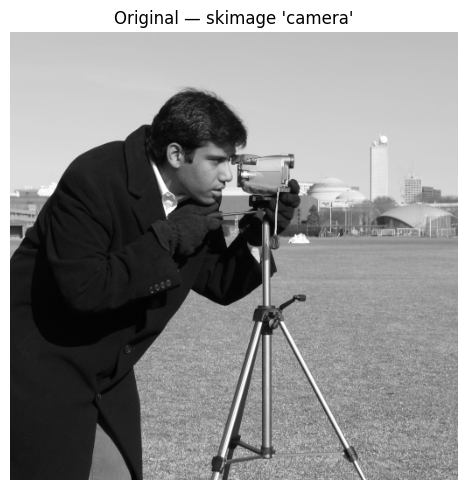

In [2]:
image = img_as_float(data.camera())

print(f"Shape: {image.shape}, dtype: {image.dtype}")
print(f"Value range: [{image.min():.2f}, {image.max():.2f}]")

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray", vmin=0, vmax=1)
plt.title("Original — skimage 'camera'")
plt.axis("off")
plt.tight_layout()
plt.show()


---
## 2. What Is a Convolution?

### The idea

A convolution kernel is just a small matrix — usually 3×3 or 5×5 — that slides
over the image one pixel at a time. At each position it multiplies its weights
against the pixel values underneath, sums everything up, and writes that number
into the output. The kernel encodes what pattern you're looking for or enhancing.

### The formula

For image $I$ and kernel $K$ of size $(2m+1) \times (2n+1)$:

$$
(I * K)[i, j] = \sum_{p=-m}^{m} \sum_{q=-n}^{n} K[p, q] \cdot I[i-p,\; j-q]
$$

Haussler (1999) formalised this: a "convolution kernel" on any composite structure
is valid as long as it can be expressed as a sum over all ways of decomposing the
input into parts — which is exactly what the sliding-window operation does.

### Output dimension formula

Given input size $H \times W$, kernel size $k$, padding $p$, stride $s$:

$$
H_{out} = \left\lfloor \frac{H + 2p - k}{s} \right\rfloor + 1
\qquad
W_{out} = \left\lfloor \frac{W + 2p - k}{s} \right\rfloor + 1
$$

LeCun et al. (1998) used this directly in LeNet-5:
- Input: 32×32, kernel: 5×5, padding: 0, stride: 1
- Output: $\lfloor(32 + 0 - 5)/1\rfloor + 1 = 28$ ✓


In [3]:
def output_size(H, W, k, p=0, s=1):
    H_out = (H + 2 * p - k) // s + 1
    W_out = (W + 2 * p - k) // s + 1
    return H_out, W_out

# Quick demo table
examples = [
    (512, 512, 3, 0, 1, "3×3 kernel, no padding"),
    (512, 512, 3, 1, 1, "3×3 kernel, pad=1  → same size output"),
    (512, 512, 5, 2, 1, "5×5 kernel, pad=2  → same size output"),
    (512, 512, 3, 0, 2, "3×3 kernel, stride=2  → half size"),
    (32,  32,  5, 0, 1, "LeNet-5 C1: 32×32 → 28×28"),
]

print(f"{'Input':>9}  {'k':>2}  {'p':>2}  {'s':>2}  {'Output':>9}  Note")
print("-" * 65)
for H, W, k, p, s, note in examples:
    ho, wo = output_size(H, W, k, p, s)
    print(f"{H}×{W:>4}  {k:>2}  {p:>2}  {s:>2}  {ho}×{wo:>6}  {note}")


    Input   k   p   s     Output  Note
-----------------------------------------------------------------
512× 512   3   0   1  510×   510  3×3 kernel, no padding
512× 512   3   1   1  512×   512  3×3 kernel, pad=1  → same size output
512× 512   5   2   1  512×   512  5×5 kernel, pad=2  → same size output
512× 512   3   0   2  255×   255  3×3 kernel, stride=2  → half size
32×  32   5   0   1  28×    28  LeNet-5 C1: 32×32 → 28×28


---
## 3. Gaussian Kernel — Smoothing / Blur

### Why?

A Gaussian kernel is a **low-pass filter**: it blurs the image by replacing each
pixel with a weighted average of its neighbours, where the weights follow a
Gaussian bell curve. Pixels close to the centre get high weight; pixels far away
get very little. The result is that high-frequency detail (fine texture, noise)
gets averaged out, while large-scale structure stays mostly intact.

### The maths

$$
G(x, y) = \frac{1}{2\pi\sigma^2} \exp\!\left(-\frac{x^2 + y^2}{2\sigma^2}\right)
$$

We sample this onto a grid and normalise so the weights sum to 1 — this keeps the
average brightness of the image unchanged.

### Parameters

| Parameter | Effect |
|-----------|--------|
| σ (sigma) | Controls how wide the bell curve is — larger σ = more blur |
| k (kernel size) | Must be large enough to cover the bell curve. Rule of thumb: `k = 6σ + 1`, rounded up to the nearest odd number |


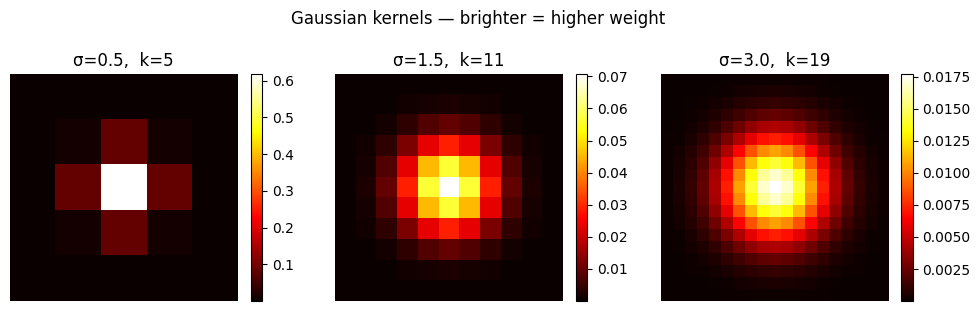

In [4]:
def gaussian_kernel(k, sigma):
    assert k % 2 == 1, "kernel size must be odd"
    centre = k // 2
    # Build a 1D array like [-2, -1, 0, 1, 2] for k=5
    coords = np.arange(k) - centre
    # meshgrid turns the 1D coords into a 2D grid of (x, y) positions
    x, y = np.meshgrid(coords, coords)
    K = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    K /= K.sum()  # normalise so weights sum to 1
    return K

# Visualise the kernel shape at three different sigma values
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, sigma in zip(axes, [0.5, 1.5, 3.0]):
    k = max(3, int(6 * sigma + 1) | 1)  # |1 forces the number to be odd
    K = gaussian_kernel(k, sigma)
    im = ax.imshow(K, cmap="hot", interpolation="nearest")
    ax.set_title(f"σ={sigma},  k={k}")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Gaussian kernels — brighter = higher weight", y=1.02)
plt.tight_layout()
plt.show()


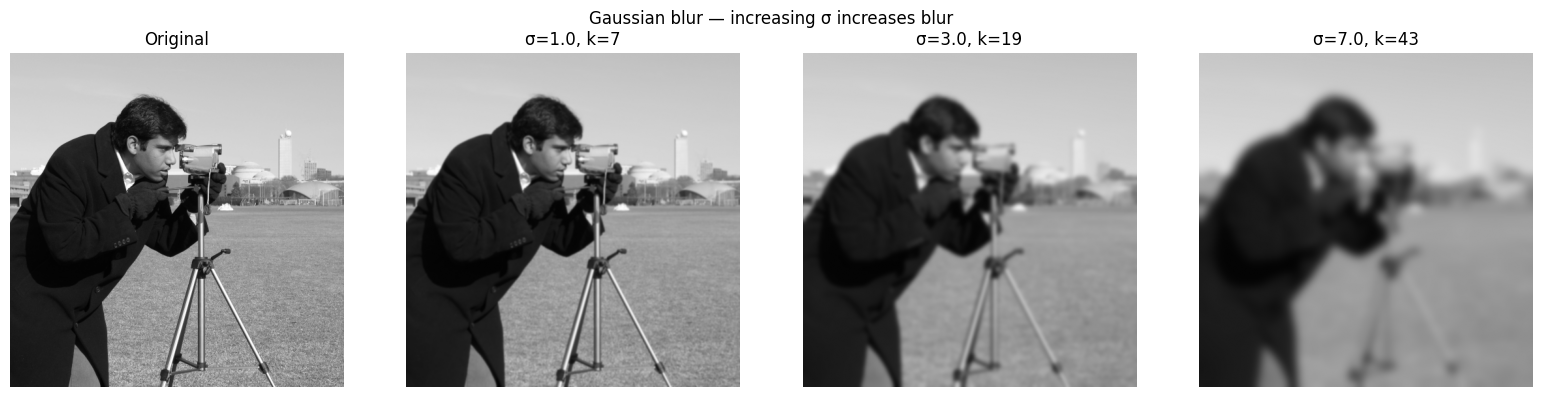

In [5]:
# Apply Gaussian at three increasing sigma values and compare
Sx_sobel = np.array([[-1,0,+1],[-2,0,+2],[-1,0,+1]], dtype=float)  # needed later
Sy_sobel = np.array([[-1,-2,-1],[0,0,0],[+1,+2,+1]], dtype=float)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original")
axes[0].axis("off")

for ax, sigma in zip(axes[1:], [1.0, 3.0, 7.0]):
    k = max(3, int(6 * sigma + 1) | 1)
    blurred = convolve(image, gaussian_kernel(k, sigma), mode="reflect")
    ax.imshow(blurred, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"σ={sigma}, k={k}")
    ax.axis("off")

plt.suptitle("Gaussian blur — increasing σ increases blur", fontsize=12)
plt.tight_layout()
plt.show()


- **σ = 1** — subtle softening; noise is gone but edges still read clearly
- **σ = 3** — noticeable blur; individual features start merging
- **σ = 7** — heavy blur; only the big shapes survive

This makes Gaussian blurring a go-to **pre-processing step before edge detection** —
it kills noise spikes that would otherwise show up as false edges.


---
## 4. Sobel Kernel — Edge Detection

### Why?

An edge is just a place where pixel brightness changes quickly — i.e. a large
gradient. The Sobel operator approximates the image gradient in the X and Y
directions separately. Combine both and you get the edge magnitude at every pixel.

### The kernels

$$
S_x = \begin{bmatrix} -1 & 0 & +1 \\ -2 & 0 & +2 \\ -1 & 0 & +1 \end{bmatrix}
\qquad
S_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ +1 & +2 & +1 \end{bmatrix}
$$

$S_x$ fires when intensity changes left→right (vertical edges).  
$S_y$ fires when intensity changes top→bottom (horizontal edges).

**Gradient magnitude** (the full edge map):
$$G = \sqrt{G_x^2 + G_y^2}$$

**Gradient direction** (which way the edge faces):
$$\theta = \arctan\!\left(G_y / G_x\right)$$


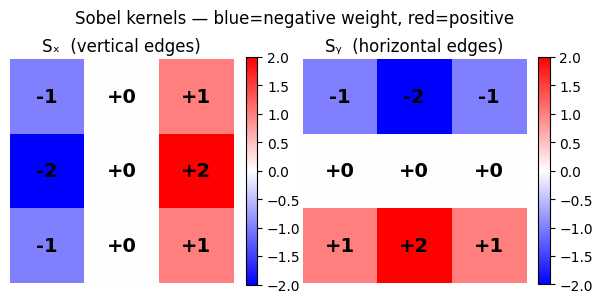

In [6]:
Sx = np.array([[-1, 0, +1],
               [-2, 0, +2],
               [-1, 0, +1]], dtype=float)

Sy = np.array([[-1, -2, -1],
               [ 0,  0,  0],
               [+1, +2, +1]], dtype=float)

# Show the kernel values so you can see the pattern
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, K, label in zip(axes, [Sx, Sy], ["Sₓ  (vertical edges)", "Sᵧ  (horizontal edges)"]):
    im = ax.imshow(K, cmap="bwr", vmin=-2, vmax=2, interpolation="nearest")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{int(K[i,j]):+d}", ha="center", va="center",
                    fontsize=14, fontweight="bold")
    ax.set_title(label)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Sobel kernels — blue=negative weight, red=positive")
plt.tight_layout()
plt.show()


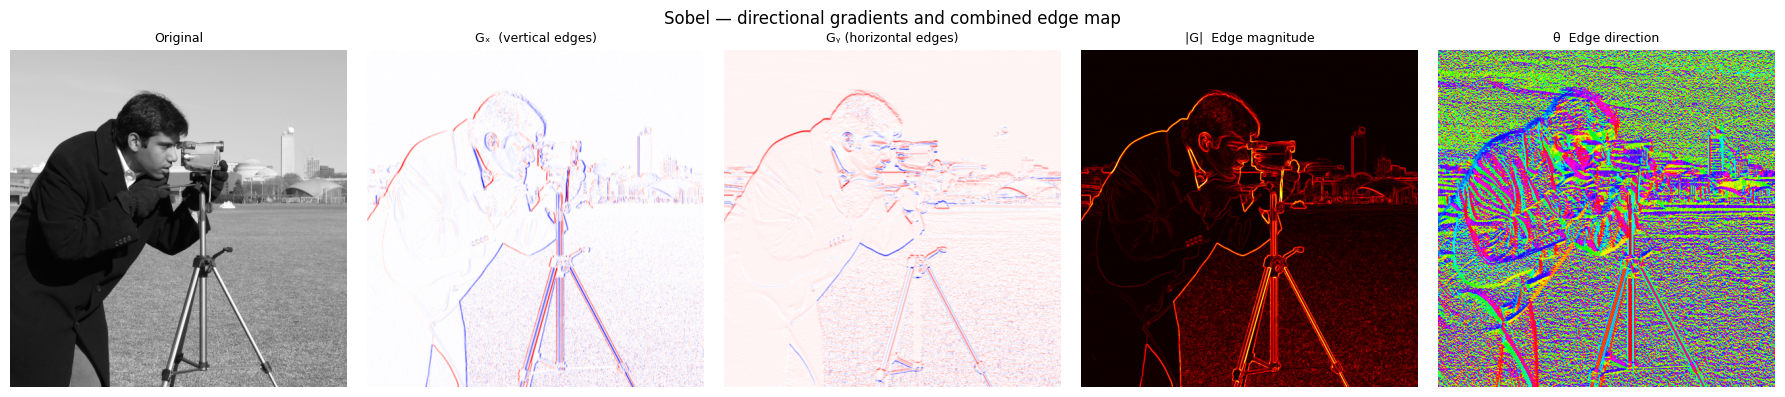

In [7]:
# Apply both Sobel kernels
Gx = convolve(image, Sx, mode="reflect")
Gy = convolve(image, Sy, mode="reflect")

# Combine into a single edge magnitude map
G_mag = np.sqrt(Gx**2 + Gy**2)

# Gradient direction in degrees — tells you the orientation of each edge
G_dir = np.degrees(np.arctan2(Gy, Gx))

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
panels = [
    (image,  "Original",              "gray", None, None),
    (Gx,     "Gₓ  (vertical edges)", "bwr",  None, None),
    (Gy,     "Gᵧ (horizontal edges)","bwr",  None, None),
    (G_mag,  "|G|  Edge magnitude",   "hot",  None, None),
    (G_dir,  "θ  Edge direction",     "hsv",  -180, 180),
]
for ax, (arr, title, cmap, vmin, vmax) in zip(axes, panels):
    ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.suptitle("Sobel — directional gradients and combined edge map", fontsize=12)
plt.tight_layout()
plt.show()


- **Gₓ** lights up the sides of objects — vertical boundaries
- **Gᵧ** lights up the tops and bottoms of objects — horizontal boundaries
- **|G|** is the complete edge map: bright = strong edge, regardless of direction
- **θ** encodes the edge angle — different colours in the HSV map = different orientations

---
## 5. Laplacian Kernel — Second Derivative & Sharpening

### Why?

Sobel gives us the first derivative of the image — it's large wherever brightness
is changing. The Laplacian gives us the **second derivative** — it's large wherever
the rate of change is itself changing. In practice this means it peaks right *at*
the edge and crosses zero between the bright and dark sides. Those zero-crossings
mark the edge location with sub-pixel precision.

The Laplacian is also used for **sharpening**: adding it back to the original image
enhances edges by amplifying the contrast that's already there.

### The kernels

$$
L_4 = \begin{bmatrix} 0 & +1 & 0 \\ +1 & -4 & +1 \\ 0 & +1 & 0 \end{bmatrix}
\qquad
L_8 = \begin{bmatrix} +1 & +1 & +1 \\ +1 & -8 & +1 \\ +1 & +1 & +1 \end{bmatrix}
$$

$L_4$: only the 4 cardinal neighbours. $L_8$: includes the 4 diagonals too — more isotropic.

**Laplacian of Gaussian (LoG):** smooth the image with a Gaussian first, then apply
the Laplacian. This stops the Laplacian amplifying noise before you find real edges.


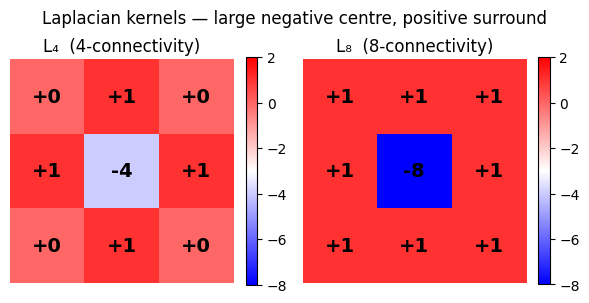

In [8]:
L4 = np.array([[ 0,  1,  0],
               [ 1, -4,  1],
               [ 0,  1,  0]], dtype=float)

L8 = np.array([[ 1,  1,  1],
               [ 1, -8,  1],
               [ 1,  1,  1]], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, K, label in zip(axes, [L4, L8], ["L₄  (4-connectivity)", "L₈  (8-connectivity)"]):
    im = ax.imshow(K, cmap="bwr", vmin=-8, vmax=2, interpolation="nearest")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{int(K[i,j]):+d}", ha="center", va="center",
                    fontsize=14, fontweight="bold")
    ax.set_title(label)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Laplacian kernels — large negative centre, positive surround")
plt.tight_layout()
plt.show()


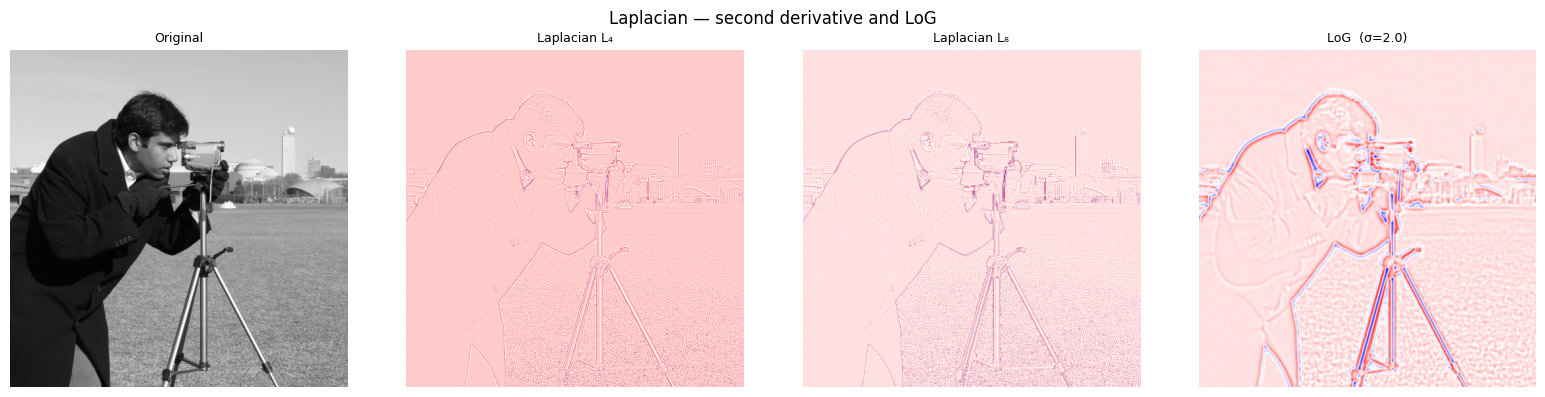

In [9]:
lap4 = convolve(image, L4, mode="reflect")
lap8 = convolve(image, L8, mode="reflect")

# Laplacian of Gaussian: blur first, then differentiate
sigma_log = 2.0
k_log     = max(3, int(6 * sigma_log + 1) | 1)
smoothed  = convolve(image, gaussian_kernel(k_log, sigma_log), mode="reflect")
log_resp  = convolve(smoothed, L8, mode="reflect")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
panels = [
    (image,    "Original",               "gray", 0,    1),
    (lap4,     "Laplacian L₄",           "bwr",  None, None),
    (lap8,     "Laplacian L₈",           "bwr",  None, None),
    (log_resp, f"LoG  (σ={sigma_log})",  "bwr",  None, None),
]
for ax, (arr, title, cmap, vmin, vmax) in zip(axes, panels):
    ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.suptitle("Laplacian — second derivative and LoG", fontsize=12)
plt.tight_layout()
plt.show()


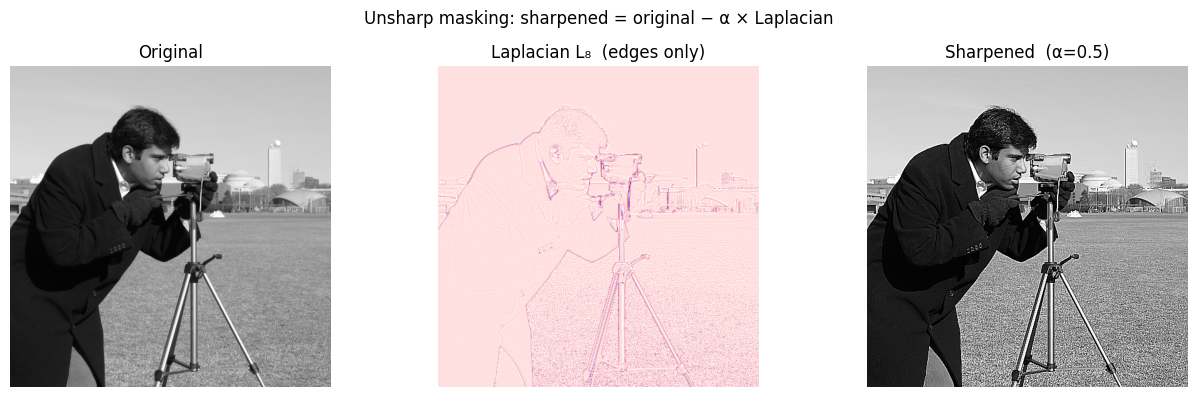

In [10]:
# Sharpening: original minus a fraction of the Laplacian.
# The Laplacian is negative at bright peaks and positive in dark valleys,
# so subtracting it pulls bright peaks brighter and dark valleys darker — sharpening.
alpha = 0.5

sharpened = np.clip(image - alpha * lap8, 0, 1)  # clip keeps values in [0, 1]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (arr, title, cmap) in zip(axes, [
    (image,     "Original",                     "gray"),
    (lap8,      "Laplacian L₈  (edges only)",   "bwr"),
    (sharpened, f"Sharpened  (α={alpha})",       "gray"),
]):
    ax.imshow(arr, cmap=cmap, vmin=(0 if cmap=="gray" else None), vmax=(1 if cmap=="gray" else None))
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Unsharp masking: sharpened = original − α × Laplacian", fontsize=12)
plt.tight_layout()
plt.show()


- The Laplacian response is positive just inside a bright edge, negative just outside —
  that zero-crossing sits right at the edge boundary
- **L₈** includes diagonals so it catches diagonal edges that L₄ misses
- The **LoG** is much cleaner — the prior Gaussian means the Laplacian doesn't
  amplify random noise spikes into false edges
- **Sharpening** works because you're literally adding back the contrast that
  was there — it's used in photography, medical imaging, satellite imagery


---
## 6. Parameter Sensitivity — What Happens When You Twist the Knobs?


### 6.1 Gaussian σ — How Much Edge Information Survives?

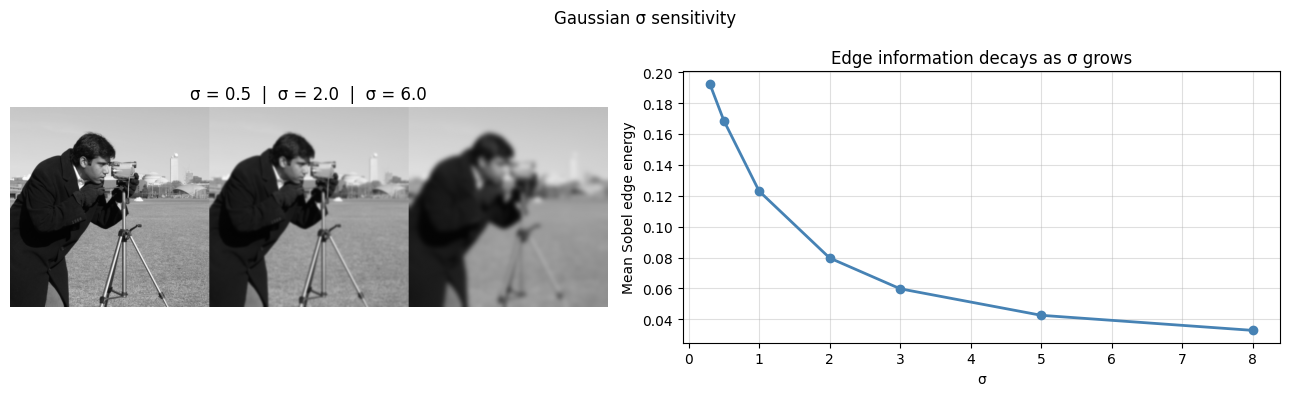

In [11]:
# A concrete way to measure the effect of sigma: after blurring, how strong
# are the edges? We compute the mean Sobel magnitude as a proxy.
sigmas = [0.3, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0]
edge_energy = []

for s in sigmas:
    k = max(3, int(6 * s + 1) | 1)
    blurred = convolve(image, gaussian_kernel(k, s), mode="reflect")
    gx = convolve(blurred, Sx, mode="reflect")
    gy = convolve(blurred, Sy, mode="reflect")
    edge_energy.append(np.mean(np.sqrt(gx**2 + gy**2)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: visual side-by-side at three extreme sigmas
imgs = []
for s in [0.5, 2.0, 6.0]:
    k = max(3, int(6 * s + 1) | 1)
    imgs.append(convolve(image, gaussian_kernel(k, s), mode="reflect"))
axes[0].imshow(np.concatenate(imgs, axis=1), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("σ = 0.5  |  σ = 2.0  |  σ = 6.0")
axes[0].axis("off")

# Right: quantitative edge energy curve
axes[1].plot(sigmas, edge_energy, "o-", color="steelblue", linewidth=2)
axes[1].set_xlabel("σ")
axes[1].set_ylabel("Mean Sobel edge energy")
axes[1].set_title("Edge information decays as σ grows")
axes[1].grid(True, alpha=0.4)

plt.suptitle("Gaussian σ sensitivity", fontsize=12)
plt.tight_layout()
plt.show()


### 6.2 Stride — Resolution vs. Computational Cost

High stride reduces the output size by skipping positions as the kernel slides.
This trades spatial detail for computational savings, a key design decision in CNN architectures.

**Important implementation note:** what we demonstrate below is *post-hoc downsampling*,
we convolve at full resolution first, then take every s-th pixel. This is a visual
approximation of strided convolution.

True strided convolution moves the kernel s pixels at a time *during* the sliding window
operation, which is what happens inside CNNs. The output looks the same but the computation
saved is different, post-hoc downsampling still does the full convolution first, whereas
true strided convolution skips positions entirely and is therefore faster.

In deep learning frameworks this would be written as:
`nn.Conv2d(1, 1, kernel_size=3, stride=2, padding=0)` in PyTorch.
OpenCV does not expose stride directly as it is primarily used for single-pass operations.

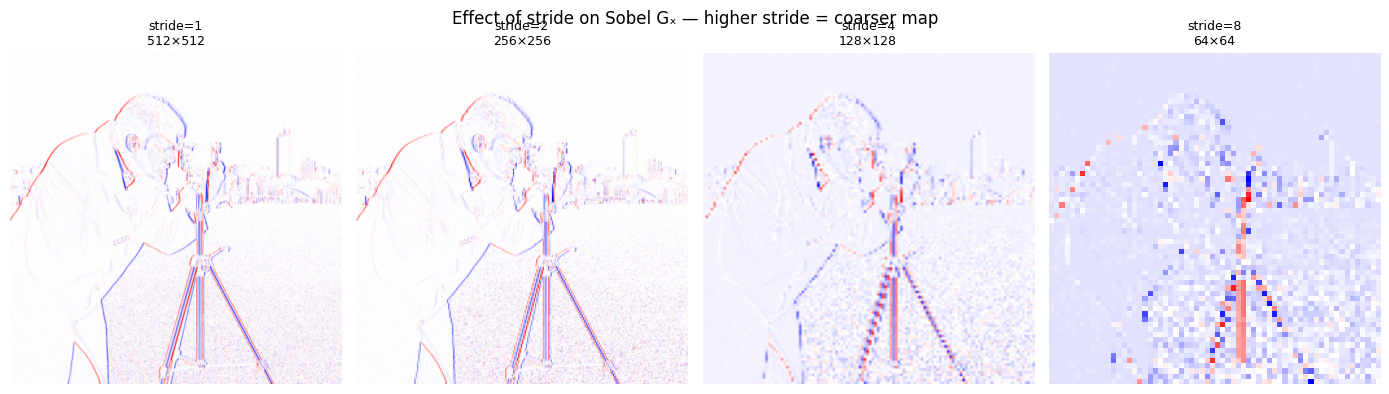

In [21]:
strides = [1, 2, 4, 8]
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, s in zip(axes, strides):
    full = convolve(image, Sx, mode="reflect")
    result = full[::s, ::s]  # post-hoc downsample — see note above
    ax.imshow(result, cmap="bwr")
    ax.set_title(f"stride={s}\n{result.shape[0]}×{result.shape[1]}", fontsize=9)
    ax.axis("off")

plt.suptitle("Effect of stride on Sobel Gₓ — higher stride = coarser map", fontsize=12)
plt.tight_layout()
plt.show()

As stride increases the output shrinks and fine details disappear.
At stride=8 on a 512×512 image, the output is only 64×64 — thin lines and small
objects are gone entirely. This is why CNNs typically use stride=1 in early layers
where spatial detail matters, and stride=2 only when intentional downsampling is needed.

### 6.3 LoG σ — Which Scale of Edges Gets Detected?

In [ ]:
log_sigmas = [0.5, 1.0, 2.0, 4.0]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for col, s in enumerate(log_sigmas):
    k = max(3, int(6 * s + 1) | 1)
    smoothed   = convolve(image, gaussian_kernel(k, s), mode="reflect")
    log_result = convolve(smoothed, L8, mode="reflect")

    # Zero-crossings: find pixels where the sign of the LoG flips compared to
    # at least one neighbour. Those sign-flip locations are the edge boundaries.
    def zero_cross(patch):
        centre = patch[4]  # patch is a flattened 3×3, centre is index 4
        return 1.0 if np.any(patch * centre < 0) else 0.0

    zc = generic_filter(log_result, zero_cross, size=3)

    axes[0, col].imshow(log_result, cmap="bwr")
    axes[0, col].set_title(f"LoG  σ={s}, k={k}", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(zc, cmap="gray")
    axes[1, col].set_title(f"Zero-crossings  σ={s}", fontsize=9)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("LoG response")
axes[1, 0].set_ylabel("Edge map")
plt.suptitle("LoG — σ controls which scale of features counts as an 'edge'", fontsize=12)
plt.tight_layout()
plt.show()



KeyboardInterrupt



- **Small σ** → picks up fine texture and noise — very busy edge map
- **Large σ** → only coarse boundaries — clean but misses detail
- This scale-space idea is why deep networks stack many layers with increasing
  receptive fields: each layer effectively sees features at a coarser scale
  (LeCun et al., 1998; Krizhevsky et al., 2012)


---
## 7. Full Pipeline — Gaussian → Sobel → Threshold

A typical classical edge-detection pipeline chains the three operations:

```
Original  →  [Gaussian blur]  →  [Sobel]  →  [Threshold]  →  Binary edge map
```

Each step shown below. Try changing `SIGMA` and `THRESHOLD` and re-running to
see the trade-off between noise and missed edges.


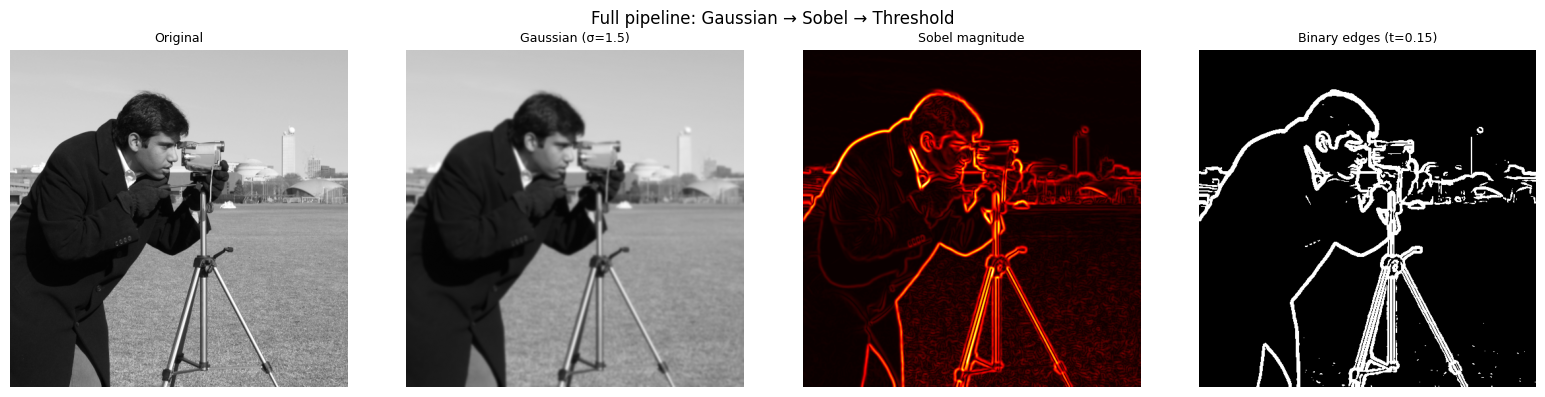

Pixels marked as edges: 25804  (9.8% of image)


In [ ]:
SIGMA     = 1.5   # how much to blur before detecting edges
THRESHOLD = 0.15  # anything above this counts as an edge (after normalising to [0,1])

# Step 1: suppress noise with Gaussian
k = max(3, int(6 * SIGMA + 1) | 1)
step1 = convolve(image, gaussian_kernel(k, SIGMA), mode="reflect")

# Step 2: find edges with Sobel
gx    = convolve(step1, Sx, mode="reflect")
gy    = convolve(step1, Sy, mode="reflect")
step2 = np.sqrt(gx**2 + gy**2)
step2_norm = step2 / step2.max()  # normalise to [0,1] so threshold makes sense

# Step 3: binarise — above threshold = edge, below = background
step3 = (step2_norm >= THRESHOLD).astype(float)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, arr, title, cmap, vmin, vmax in [
    (axes[0], image,      "Original",                    "gray", 0, 1),
    (axes[1], step1,      f"Gaussian (σ={SIGMA})",       "gray", 0, 1),
    (axes[2], step2_norm, "Sobel magnitude",             "hot",  0, 1),
    (axes[3], step3,      f"Binary edges (t={THRESHOLD})","gray", 0, 1),
]:
    ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.suptitle("Full pipeline: Gaussian → Sobel → Threshold", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Pixels marked as edges: {int(step3.sum())}  ({100*step3.mean():.1f}% of image)")


**Increasing SIGMA** → smoother edge map, fewer false edges, but some real edges get blurred away.  
**Lowering THRESHOLD** → more edges detected, but also more noise.

This precision/recall trade-off is exactly what learned kernels (LeCun et al., 1998)
address — instead of manually tuning σ and the threshold, back-propagation finds the
filter weights and threshold jointly that minimise the actual task error.


## 8. Failure Cases — When Kernels Go Wrong

Understanding when kernels fail is just as important as knowing when they work.
Every kernel family has assumptions — when those assumptions break, the output
becomes unreliable or misleading. Here we demonstrate three real failure modes.

### Failure 1: Laplacian Without Gaussian Pre-Smoothing

The Laplacian is a second-order derivative operator — it is extremely sensitive
to rapid local changes. On a clean image this is useful. On a noisy image it is
catastrophic: every noise spike gets amplified into a false edge response.

The fix is the **Laplacian of Gaussian (LoG)** — blur first, then differentiate.
The Gaussian suppresses noise before the Laplacian can amplify it.

In [ ]:
# Add realistic noise to the image
noise       = np.random.normal(0, 0.05, image.shape)
noisy_image = np.clip(image + noise, 0, 1)

# Laplacian with no pre-smoothing — noise gets amplified
lap_noisy = convolve(noisy_image, L8, mode="reflect")

# LoG — Gaussian first, then Laplacian — noise suppressed
lap_smoothed = convolve(
    convolve(noisy_image, gaussian_kernel(9, 1.5), mode="reflect"),
    L8, mode="reflect"
)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(noisy_image, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Noisy input")
axes[1].imshow(lap_noisy, cmap="bwr")
axes[1].set_title("Laplacian — no smoothing\n(noise amplified)")
axes[2].imshow(noisy_image, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Same noisy input")
axes[3].imshow(lap_smoothed, cmap="bwr")
axes[3].set_title("LoG — Gaussian first\n(noise suppressed)")

for ax in axes:
    ax.axis("off")

plt.suptitle("Failure 1: Laplacian amplifies noise without prior smoothing", fontsize=12)
plt.tight_layout()
plt.show()

### Failure 2: Large Stride Loses Spatial Detail

High stride aggressively reduces output resolution. At stride=8 on a 512×512 image
the output is only 64×64 — fine structures like thin edges and small objects
disappear entirely. Once spatial information is discarded by a large stride it
cannot be recovered in later layers.

This is why modern architectures (LeCun et al., 1998; Krizhevsky et al., 2012)
are careful about when and where stride is increased — typically only after
enough feature extraction has already taken place in earlier layers.

In [ ]:
gx_full  = convolve(image, Sx, mode="reflect")
stride_1 = gx_full[::1, ::1]
stride_8 = gx_full[::8, ::8]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(stride_1, cmap="bwr")
axes[0].set_title(f"Stride=1 — {stride_1.shape[0]}×{stride_1.shape[1]} — full detail")
axes[1].imshow(stride_8, cmap="bwr")
axes[1].set_title(f"Stride=8 — {stride_8.shape[0]}×{stride_8.shape[1]} — detail lost")

for ax in axes:
    ax.axis("off")

plt.suptitle("Failure 2: Large stride discards spatial information", fontsize=12)
plt.tight_layout()
plt.show()

### Failure 3: Zero Padding Boundary Artifacts

Zero padding fills image borders with artificial black pixels (value = 0).
When a kernel sits near the edge, some of its weights multiply against these
zeros — values that don't exist in the real image. This produces weaker and
incorrect responses near the boundary, visible as a dark ring around the output.

A common alternative is **reflect padding** (`mode='reflect'` in scipy), which
mirrors real pixel values at the border instead of inserting zeros, producing
more realistic boundary responses.

In [ ]:
# Apply Laplacian with zero padding vs reflect padding
lap_zero    = convolve(image, L8, mode="constant", cval=0)  # zero padding
lap_reflect = convolve(image, L8, mode="reflect")            # reflect padding

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(image, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original image")
axes[1].imshow(lap_zero, cmap="bwr")
axes[1].set_title("Zero padding\n(boundary artifacts visible at edges)")
axes[2].imshow(lap_reflect, cmap="bwr")
axes[2].set_title("Reflect padding\n(cleaner boundary response)")

for ax in axes:
    ax.axis("off")

plt.suptitle("Failure 3: Zero padding creates artificial boundary responses", fontsize=12)
plt.tight_layout()
plt.show()

### Summary of Failure Cases

| Failure | Cause | Fix |
|---|---|---|
| Laplacian amplifies noise | Second-order derivative sensitive to high-frequency noise | Apply Gaussian blur first (LoG) |
| Large stride loses detail | Spatial positions skipped permanently | Use stride=1 in detail-critical layers |
| Zero padding artifacts | Artificial zeros at border distort kernel responses | Use reflect or replicate padding |

These failure modes are exactly why classical pipelines chain operations carefully
(Gaussian → Sobel → Threshold) and why learned CNNs use padding strategies and
careful stride placement by design.

## 9. OpenCV Equivalents — Production-Ready Implementations

Everything we've built manually above has a highly optimised OpenCV equivalent.
OpenCV is the industry standard for computer vision, it's written in C++ under
the hood, making it significantly faster than scipy for large images or real-time
applications. 

Here we show the OpenCV versions of all three kernel families
and verify they produce the same results as our implementations above.

In [ ]:
# OpenCV works with uint8 (0-255) by default, so we convert from our float image.
# CV_64F tells OpenCV to keep the output as 64-bit float so we don't lose
# negative values (important for Sobel and Laplacian responses).
image_uint8 = (image * 255).astype(np.uint8)

In [ ]:
# ── Gaussian Blur ──────────────────────────────────────────────────────────────
# cv2.GaussianBlur(src, ksize, sigmaX)
# ksize must be a tuple of two odd numbers. sigmaX is our sigma.
blurred_cv = cv2.GaussianBlur(image_uint8, (15, 15), sigmaX=3.0)

In [ ]:
# ── Sobel ──────────────────────────────────────────────────────────────────────
# cv2.Sobel(src, ddepth, dx, dy, ksize)
# dx=1, dy=0 → Sobel X (vertical edges)
# dx=0, dy=1 → Sobel Y (horizontal edges)
# ddepth=cv2.CV_64F keeps the signed float output
sobel_x_cv  = cv2.Sobel(image_uint8, cv2.CV_64F, 1, 0, ksize=3)
sobel_y_cv  = cv2.Sobel(image_uint8, cv2.CV_64F, 0, 1, ksize=3)

# cv2.magnitude() computes sqrt(Gx² + Gy²) efficiently
magnitude_cv = cv2.magnitude(sobel_x_cv, sobel_y_cv)

In [ ]:
# ── Laplacian ──────────────────────────────────────────────────────────────────
# cv2.Laplacian(src, ddepth, ksize)
# Apply Gaussian first (LoG pattern) to avoid amplifying noise
smoothed_cv = cv2.GaussianBlur(image_uint8, (13, 13), sigmaX=2.0)
lap_cv      = cv2.Laplacian(smoothed_cv, cv2.CV_64F, ksize=3)

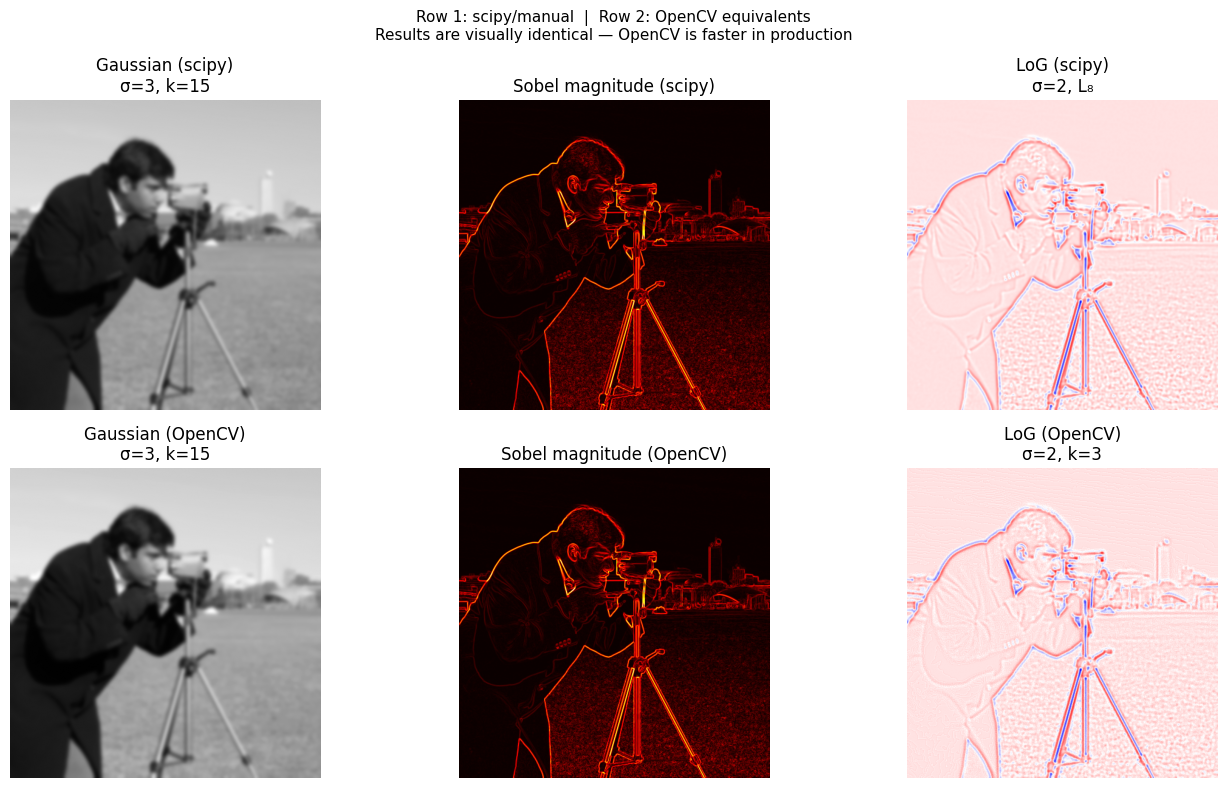

In [ ]:
# ── Visualise all three side by side with our scipy results ────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Row 1: our scipy/manual implementations
axes[0, 0].imshow(convolve(image, gaussian_kernel(15, 3.0), mode="reflect"),
                  cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Gaussian (scipy)\nσ=3, k=15")

axes[0, 1].imshow(np.sqrt(
    convolve(image, Sx, mode="reflect")**2 +
    convolve(image, Sy, mode="reflect")**2),
    cmap="hot")
axes[0, 1].set_title("Sobel magnitude (scipy)")

axes[0, 2].imshow(convolve(
    convolve(image, gaussian_kernel(13, 2.0), mode="reflect"),
    L8, mode="reflect"), cmap="bwr")
axes[0, 2].set_title("LoG (scipy)\nσ=2, L₈")

# Row 2: OpenCV equivalents
axes[1, 0].imshow(blurred_cv, cmap="gray")
axes[1, 0].set_title("Gaussian (OpenCV)\nσ=3, k=15")

axes[1, 1].imshow(magnitude_cv, cmap="hot")
axes[1, 1].set_title("Sobel magnitude (OpenCV)")

axes[1, 2].imshow(lap_cv, cmap="bwr")
axes[1, 2].set_title("LoG (OpenCV)\nσ=2, k=3")

for ax in axes.flat:
    ax.axis("off")

plt.suptitle("Row 1: scipy/manual  |  Row 2: OpenCV equivalents\n"
             "Results are visually identical — OpenCV is faster in production",
             fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# ── Verify numerically that outputs match ──────────────────────────────────────
# Normalise both to [0,1] before comparing since scipy uses float image
# and OpenCV uses uint8 — scaling differs by a factor of 255
scipy_mag = np.sqrt(
    convolve(image, Sx, mode="reflect")**2 +
    convolve(image, Sy, mode="reflect")**2)
cv_mag_norm = magnitude_cv / 255.0  # bring OpenCV result to same scale

correlation = np.corrcoef(scipy_mag.ravel(), cv_mag_norm.ravel())[0, 1]
print(f"Pearson correlation between scipy and OpenCV Sobel outputs: {correlation:.6f}")
print("(1.0 = identical structure, any value >0.99 confirms they are equivalent)")

Pearson correlation between scipy and OpenCV Sobel outputs: 0.999654
(1.0 = identical structure, any value >0.99 confirms they are equivalent)


## Why use OpenCV in practice?
- Written in optimised C++ with SIMD acceleration

- Supports GPU via CUDA (cv2.cuda module)

- Handles video streams, camera input, real-time processing

- Industry standard — used in Tesla Autopilot, medical imaging, robotics

- The scipy/skimage implementations we used above are better for learning
because they are more transparent — but for production, OpenCV is the tool.

---
## 10. Summary


**Key takeaways:**
1. A kernel is just a small matrix that slides over the image and takes a weighted sum.
2. The output dimension formula is essential: get it wrong and your tensor shapes don't match.
3. Gaussian = smoothing, Sobel = first-derivative edges, Laplacian = second-derivative / sharpening.
4. σ, kernel size, stride, and threshold all trade off against each other — always visualise intermediate results.
5. Learned kernels in CNNs converge to roughly the same shapes as these hand-crafted ones, because these shapes are genuinely useful for vision tasks.

---

**References**
- Haussler, D. (1999). *Convolution Kernels on Discrete Structures.* UCSC CRL.
- LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). *Gradient-Based Learning Applied to Document Recognition.* Proceedings of the IEEE.
- Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012). *ImageNet Classification with Deep CNNs.* NeurIPS.
